## Nova modelação

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Métricas
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Modelos Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Balanceamento de Dados
from imblearn.over_sampling import SMOTE

# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")

# Carregar os dados
ortho_clean = pd.read_csv('ortho_eda_clean.csv')


In [3]:
# 1. Converter variáveis categóricas
ortho_clean["Grupo_pre"] = ortho_clean["Grupo_pre"].astype("category")
ortho_clean["Sexo"] = ortho_clean["Sexo"].astype("category")

# 2. One-Hot Encoding (Transformar categorias em colunas binárias)
ortho_encoded = pd.get_dummies(ortho_clean, columns=['Grupo_pre', 'Sexo'], drop_first=True)

# 3. Definição de X (preditores) e y (alvo)
X = ortho_encoded.drop("mudanca_CPAK", axis=1)
y = ortho_encoded["mudanca_CPAK"]

# 4. Split Estratificado (70% Treino, 30% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 5. Escalamento dos dados (importante para Regressão Logística e XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Aplicação de SMOTE para balanceamento da classe minoritária (apenas no treino)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Dataset de treino original: {y_train.value_counts().to_dict()}")
print(f"Dataset de treino após SMOTE: {y_train_smote.value_counts().to_dict()}")

Dataset de treino original: {0: 165, 1: 18}
Dataset de treino após SMOTE: {0: 165, 1: 165}



========== Regressão Logística ==========
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        71
           1       0.28      0.62      0.38         8

    accuracy                           0.80        79
   macro avg       0.61      0.72      0.63        79
weighted avg       0.88      0.80      0.83        79

ROC AUC Score: 0.7553

========== Árvore de Decisão ==========
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        71
           1       0.00      0.00      0.00         8

    accuracy                           0.78        79
   macro avg       0.44      0.44      0.44        79
weighted avg       0.80      0.78      0.79        79

ROC AUC Score: 0.4366

========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        71
           1       0.12      0.12      0.12         8

    accuracy     

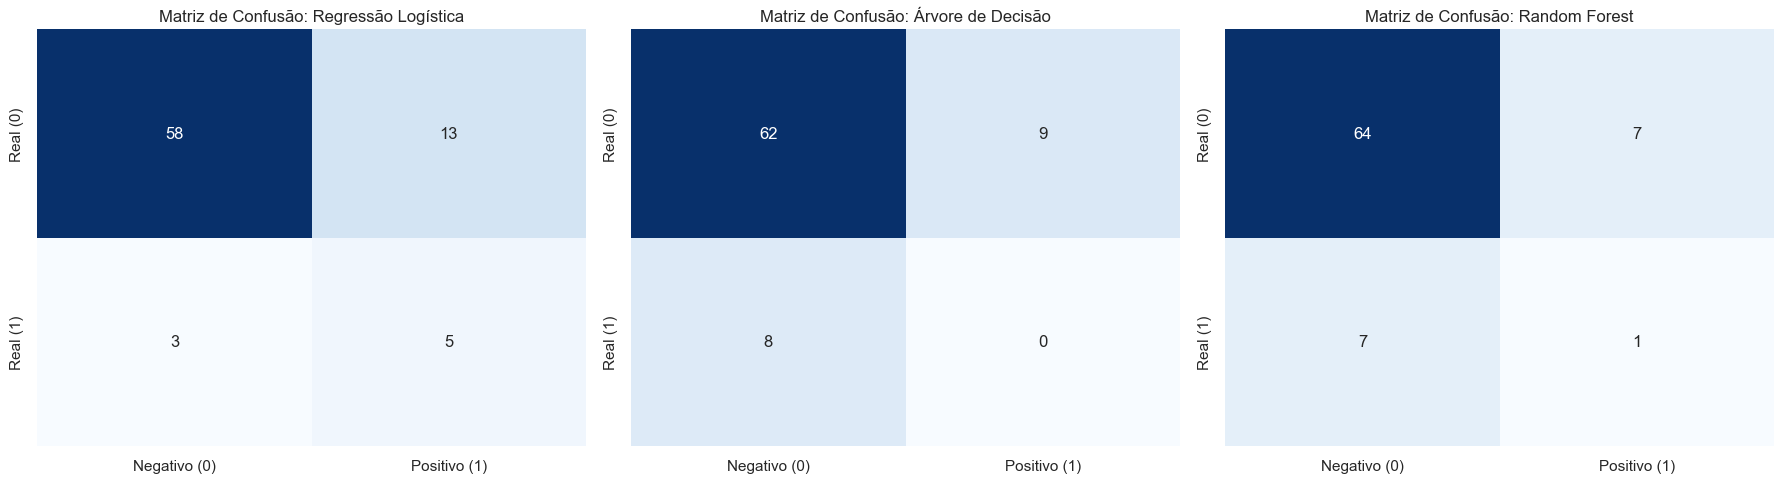

In [4]:
def avaliar_modelo(modelo, nome, X_train, y_train, X_test, y_test, ax):
    """Treina um modelo e desenha a matriz de confusão no eixo fornecido."""
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    # Print das métricas no console
    print(f"\n{'='*10} {nome} {'='*10}")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    
    # Matriz de Confusão Visual
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negativo (0)', 'Positivo (1)'],
                yticklabels=['Real (0)', 'Real (1)'], ax=ax)
    ax.set_title(f"Matriz de Confusão: {nome}")

# Execução da Comparação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [
    (LogisticRegression(random_state=42), "Regressão Logística"),
    (DecisionTreeClassifier(random_state=42), "Árvore de Decisão"),
    (RandomForestClassifier(random_state=42), "Random Forest")
]

for i, (mod, nome) in enumerate(modelos):
    avaliar_modelo(mod, nome, X_train_smote, y_train_smote, X_test_scaled, y_test, axes[i])

plt.tight_layout()
plt.show()

In [5]:
print("Iniciando Grid Search para Random Forest...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid, cv=3, scoring='recall'
)
grid_rf.fit(X_train_smote, y_train_smote)

print(f"Melhores parâmetros encontrados: {grid_rf.best_params_}")

Iniciando Grid Search para Random Forest...
Melhores parâmetros encontrados: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 100}


C:\Users\joaof\AppData\Local\Temp\ipykernel_22996\3596909034.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variável', data=importancia, palette='vlag')


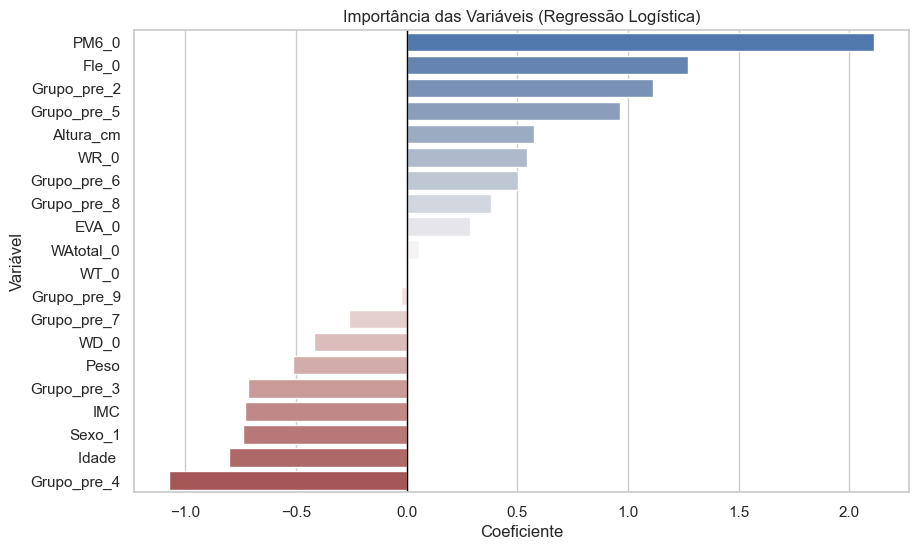

In [6]:
# Treinar o modelo final de Logística para extração de coeficientes
modelo_final_lr = LogisticRegression(random_state=42)
modelo_final_lr.fit(X_train_smote, y_train_smote)

# Criar DataFrame de importância
importancia = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_final_lr.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualização
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variável', data=importancia, palette='vlag')
plt.title('Importância das Variáveis (Regressão Logística)')
plt.axvline(0, color='black', lw=1)
plt.show()